     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


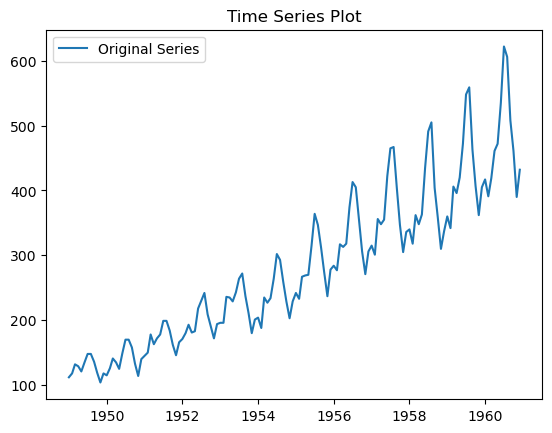

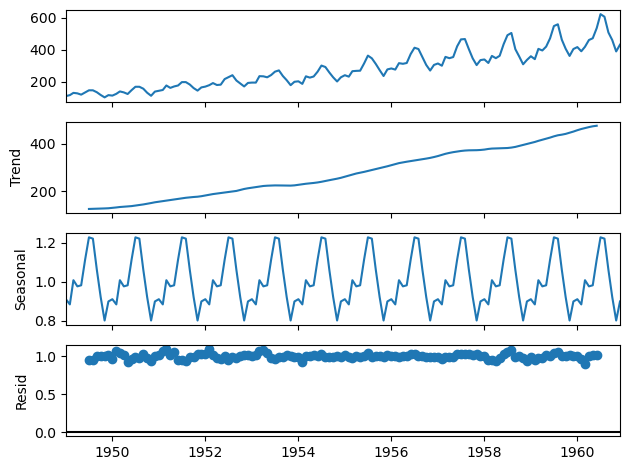

In [1]:
#6.Load a time series dataset (e.g., AirPassengers), plot the original series,
#and decompose it into trend, seasonality, and residual components
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset from local file
data = pd.read_csv("AirPassengers.csv")

# Check column names
print(data.head())

# Convert date column to datetime (change 'Month' if needed)
data['Month'] = pd.to_datetime(data['Month'])

# Set index
data.set_index('Month', inplace=True)

# Ensure correct column name (change if your column differs)
data.columns = ['Passengers']

# Plot original time series
plt.figure()
plt.plot(data, label='Original Series')
plt.title("Time Series Plot")
plt.legend()
plt.show()

# Decompose the series (use additive if multiplicative doesn't fit)
decomposition = seasonal_decompose(data, model='multiplicative')

# Plot decomposition
decomposition.plot()
plt.show()

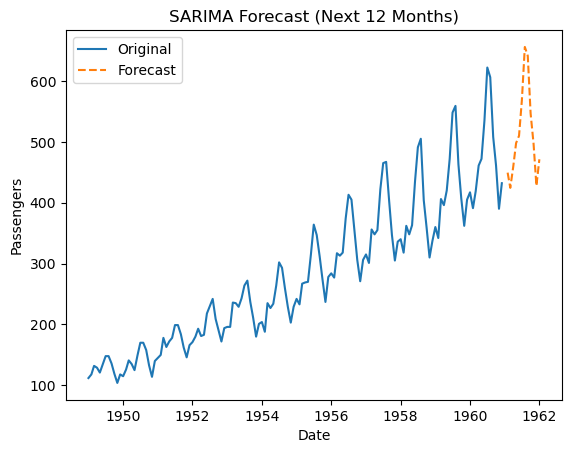

In [2]:
#8.Train a SARIMA model on the monthly airline passengers dataset.
#Forecast the next 12 months and visualize the results.
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = pd.read_csv("AirPassengers.csv")

# Convert to datetime and set index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
data.columns = ['Passengers']

# Train SARIMA model
# (p,d,q) × (P,D,Q, s) where s=12 for monthly seasonality
model = SARIMAX(data['Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

results = model.fit()

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean

# Create future dates
future_dates = pd.date_range(start=data.index[-1], periods=13, freq='M')[1:]

# Plot original + forecast
plt.figure()
plt.plot(data.index, data['Passengers'], label='Original')
plt.plot(future_dates, forecast_mean, label='Forecast', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.title("SARIMA Forecast (Next 12 Months)")
plt.legend()
plt.show()

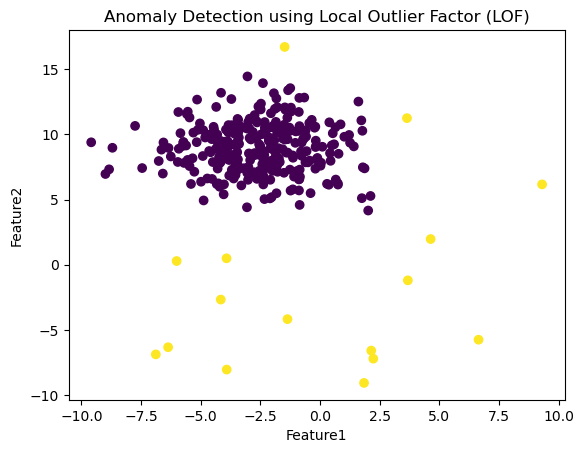

In [3]:
#9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect
#anomalies and visualize them using matplotlib.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

# Generate dataset
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=2, random_state=42)

# Add some anomalies
rng = np.random.RandomState(42)
anomalies = rng.uniform(low=-10, high=10, size=(20, 2))

# Combine normal data and anomalies
X = np.vstack([X, anomalies])

# Convert to DataFrame
data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
data['anomaly'] = lof.fit_predict(data[['Feature1', 'Feature2']])

# Convert labels: -1 → anomaly, 1 → normal
data['anomaly'] = data['anomaly'].map({1: 0, -1: 1})

# Plot
plt.figure()
plt.scatter(data['Feature1'], data['Feature2'], c=data['anomaly'])
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Anomaly Detection using Local Outlier Factor (LOF)")
plt.show()